## 🩺 Pneumonia Diagnosis from Chest X-Rays Using Deep Learning

This notebook presents a **complete clinical-oriented deep learning pipeline** for the automated detection of pneumonia from chest X-ray images. The workflow is designed with a strong emphasis on **medical reliability and interpretability**, following best practices for clinical AI applications.

The pipeline includes:

* **Transfer Learning** using state-of-the-art convolutional neural networks (DenseNet121 and EfficientNetB0)
* **Clinical threshold optimization**, prioritizing high sensitivity (recall) to minimize false negatives
* Model evaluation using **medically relevant performance metrics**
* Export of the trained model for deployment or further validation
* **Grad-CAM visualization** to enhance model explainability and support clinical decision-making

The objective of this project is to demonstrate how deep learning models can be developed, evaluated, and interpreted responsibly in a healthcare context, particularly for high-risk diagnostic tasks such as pneumonia detection.

## 1️. Import Packages and Functions

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import cv2
import datetime
import uuid


from inference import hospital_inference
from logger import log_inference

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import load_model

from tensorflow.keras.applications import DenseNet121, EfficientNetB0
from tensorflow.keras.applications.densenet import preprocess_input as densenet_preprocess
from tensorflow.keras.applications.efficientnet import preprocess_input as effnet_preprocess

from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

from sklearn.calibration import calibration_curve
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc

2025-12-24 11:48:29.080350: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-12-24 11:48:29.244740: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-12-24 11:48:34.103016: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
/home/anderjcruz/Deep-Learning/venvdl/lib/python3.12/site-packages/keras/src/exp

In [2]:
os.listdir("chest_xray")

['test', 'train', 'val']

In [3]:
len(os.listdir("chest_xray/train/PNEUMONIA"))

3875

## 2. Data Visualization and Directory Structure

In this section, we define the **core configuration parameters** for image processing and model training, as well as the **directory structure** used to organize the dataset.

* All chest X-ray images are resized to **224 × 224 pixels**, ensuring compatibility with the selected pre-trained convolutional neural networks.
* A **batch size of 16** is used to balance computational efficiency and memory constraints.
* The model is trained for **10 epochs**, serving as an initial training configuration for evaluation and tuning.

The dataset is organized into three distinct subsets:

* **Training set (`train_dir`)**: used to learn model parameters
* **Validation set (`val_dir`)**: used for hyperparameter tuning and threshold optimization
* **Test set (`test_dir`)**: used exclusively for final, unbiased performance evaluation

This directory-based structure follows standard deep learning practices and supports reproducible experimentation in medical image analysis.

In [4]:
IMG_SIZE = 224
BATCH_SIZE = 16
EPOCHS = 10


train_dir = 'chest_xray/train'
val_dir = 'chest_xray/val'
test_dir = 'chest_xray/test'

Train set:
PNEUMONIA=3875
NORMAL=1341
Test set:
PNEUMONIA = 390
NORMAL = 234
Validation set:
PNEUMONIA = 8
NORMAL = 8


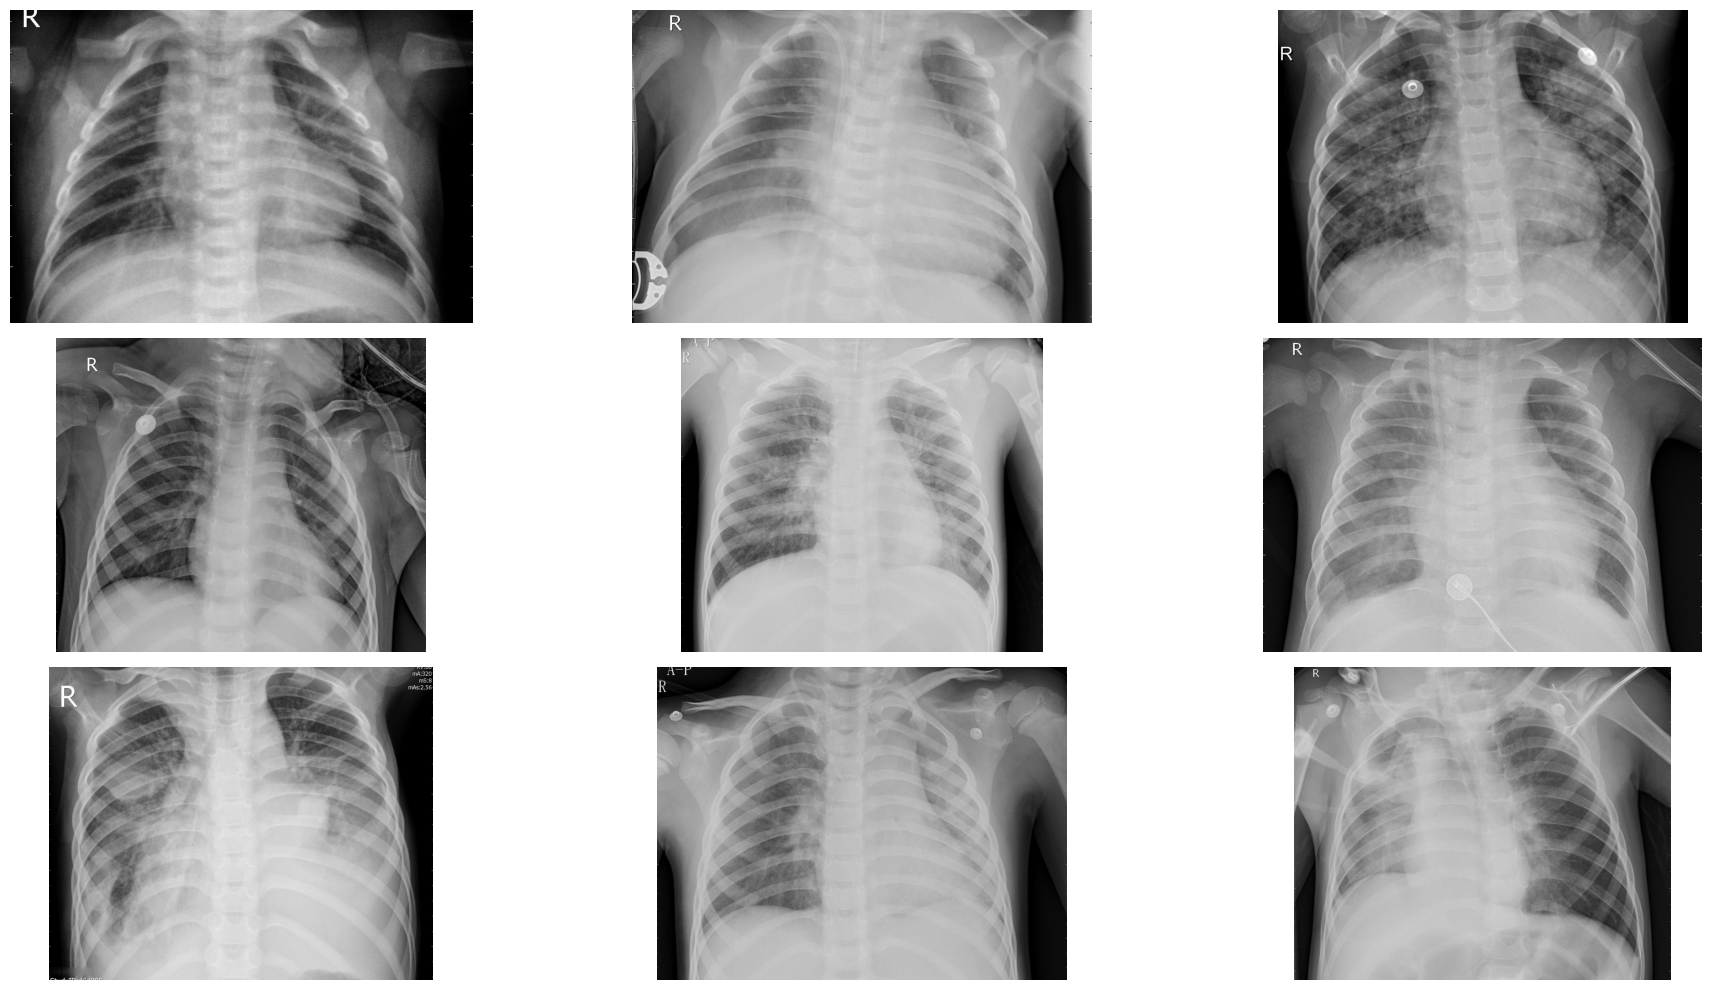

In [5]:
print("Train set:\n========================================")
num_pneumonia = len(os.listdir(os.path.join(train_dir, 'PNEUMONIA')))
num_normal = len(os.listdir(os.path.join(train_dir, 'NORMAL')))
print(f"PNEUMONIA={num_pneumonia}")
print(f"NORMAL={num_normal}")

print("Test set:\n========================================")
print(f"PNEUMONIA = {len(os.listdir(os.path.join(test_dir, 'PNEUMONIA')))}")
print(f"NORMAL = {len(os.listdir(os.path.join(test_dir, 'NORMAL')))}")

print("Validation set:\n========================================")
print(f"PNEUMONIA = {len(os.listdir(os.path.join(val_dir, 'PNEUMONIA')))}")
print(f"NORMAL = {len(os.listdir(os.path.join(val_dir, 'NORMAL')))}")

pneumonia = os.listdir("chest_xray/train/PNEUMONIA")
pneumonia_dir = "chest_xray/train/PNEUMONIA"

plt.figure(figsize=(20, 10))

for i in range(9):
    plt.subplot(3, 3, i + 1)
    img = plt.imread(os.path.join(pneumonia_dir, pneumonia[i]))
    plt.imshow(img, cmap='gray')
    plt.axis('off')
    
plt.tight_layout()

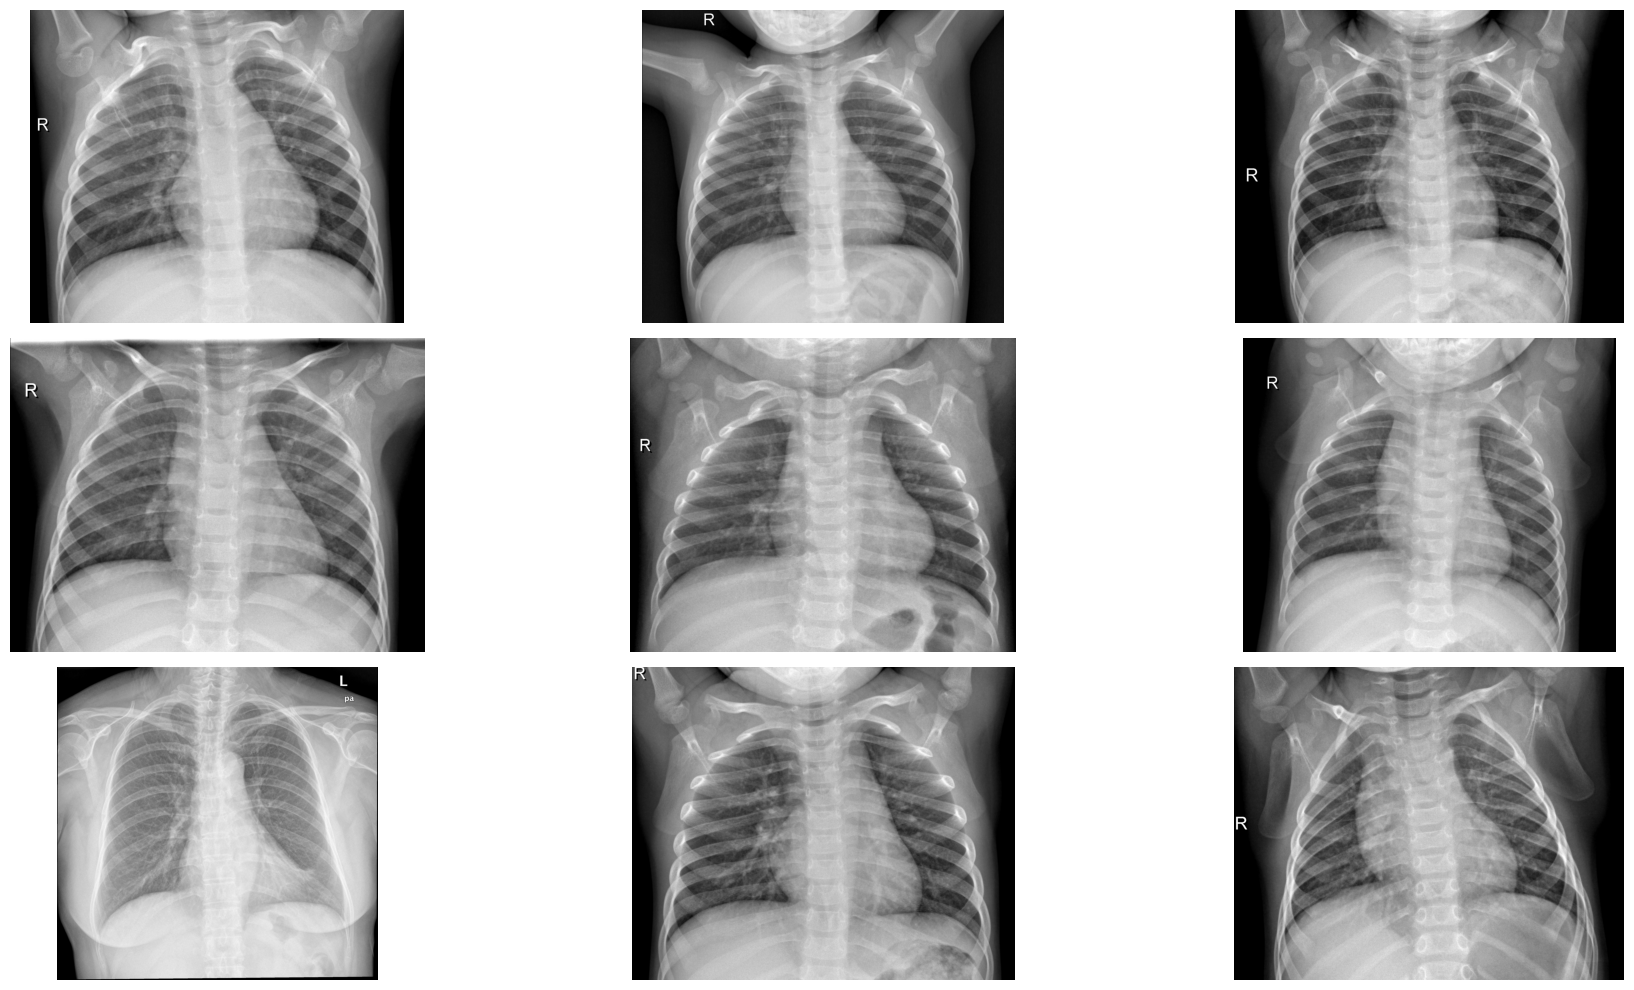

In [6]:
normal = os.listdir("chest_xray/train/NORMAL")
normal_dir = "chest_xray/train/NORMAL"

plt.figure(figsize=(20, 10))

for i in range(9):
    plt.subplot(3, 3, i + 1)
    img = plt.imread(os.path.join(normal_dir, normal[i]))
    plt.imshow(img, cmap='gray')
    plt.axis('off')
    
plt.tight_layout()

## 3. Data Preprocessing and Image Augmentation

This section defines the **data preprocessing and augmentation strategy** used to prepare chest X-ray images for model training and evaluation.

### Training Data Augmentation

To improve model generalization and reduce overfitting, **realistic data augmentation** techniques are applied to the training set. These transformations simulate common variations in chest X-ray acquisition while preserving clinical relevance:

* Rotation up to **±20 degrees**
* Horizontal and vertical shifts up to **10%**
* Zoom variations up to **10%**
* **Horizontal flipping**
* Model-specific input normalization using the **DenseNet preprocessing function**

### Validation and Test Preprocessing

For the validation and test sets, **no augmentation is applied**. Only the same preprocessing function is used to ensure consistency with the trained model while preserving the original image characteristics for unbiased evaluation.

### Data Loading

Images are loaded from directory-based datasets using a binary classification setup:

* **Training generator**: shuffled batches for stochastic learning
* **Validation generator**: non-shuffled to ensure reproducible evaluation
* **Test generator**: batch size of 1 and no shuffling to enable precise per-image predictions and metric computation

This preprocessing pipeline follows best practices in **medical image analysis**, ensuring data integrity while enhancing model robustness.

### 3️.1 ImageDataGenerator

In [7]:
train_datagen = ImageDataGenerator(
    preprocessing_function=densenet_preprocess,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)

val_test_datagen = ImageDataGenerator(
    preprocessing_function=densenet_preprocess
)

In [8]:
train = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=True
)

validation = val_test_datagen.flow_from_directory(
    val_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

test = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=1,
    class_mode='binary',
    shuffle=False
)

Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


### 3.2 Class Weights (dataset desbalanced)

In [9]:
num_pneumonia = len(os.listdir(os.path.join(train_dir, 'PNEUMONIA')))
num_normal = len(os.listdir(os.path.join(train_dir, 'NORMAL')))

class_weight = {
    0: num_pneumonia / (num_pneumonia + num_normal),
    1: num_normal / (num_pneumonia + num_normal)
}

class_weight

{0: 0.7429064417177914, 1: 0.2570935582822086}

### 3.3 Model Architecture – DenseNet121

This section describes the deep learning model architecture used for pneumonia classification based on **DenseNet121** with **transfer learning**.

#### Base Network

A **DenseNet121** architecture pre-trained on the **ImageNet** dataset is used as the feature extractor. The top (classification) layers are removed, and the convolutional base is **frozen** to preserve previously learned visual features while reducing training time and overfitting.

#### Classification Head

On top of the convolutional backbone, a custom classification head is added:

* **Global Average Pooling** to reduce spatial dimensions and model complexity
* A fully connected layer with **256 neurons and ReLU activation** for feature abstraction
* **Dropout (0.4)** to improve regularization and reduce overfitting
* A final **sigmoid-activated output neuron** for binary classification (pneumonia vs. normal)

#### Model Compilation

The model is compiled using the **Adam optimizer** with a learning rate of **1e-3** and optimized using **binary cross-entropy loss**, which is appropriate for binary medical classification tasks.

To ensure clinically meaningful evaluation, the following metrics are monitored during training:

* **Accuracy**
* **Precision** (false positive control)
* **Recall (Sensitivity)** – critical for minimizing missed pneumonia cases
* **AUC (Area Under the ROC Curve)** for threshold-independent performance assessment

This architecture balances performance, interpretability, and computational efficiency, making it suitable for clinical-oriented pneumonia detection tasks.

In [10]:
base_model = DenseNet121(
    include_top=False, 
    weights='imagenet', 
    input_shape=(IMG_SIZE,IMG_SIZE,3)
    )
base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.4)(x)
output = Dense(1, activation='sigmoid')(x)

model = Model(base_model.input, output)

model.compile(
    optimizer=Adam(1e-3),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall'),
        tf.keras.metrics.AUC(name='auc')
    ]
)

I0000 00:00:1766587722.361569   29740 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1766 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


### 3.4 Model Training

In this stage, the model is trained using the prepared training and validation datasets.

The number of **steps per epoch** and **validation steps** is calculated based on the total number of samples and the defined batch size, ensuring that each epoch processes the full dataset efficiently.

In [11]:
steps_per_epoch = train.samples // train.batch_size
validation_steps = validation.samples // validation.batch_size

history = model.fit(
    train,
    epochs=EPOCHS,
    validation_data=validation,
    steps_per_epoch=steps_per_epoch,
    validation_steps=validation_steps,
    class_weight=class_weight
)

Epoch 1/10


2025-12-24 11:48:52.431554: I external/local_xla/xla/service/service.cc:163] XLA service 0x776168014f40 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-12-24 11:48:52.431603: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 3050 Laptop GPU, Compute Capability 8.6
2025-12-24 11:48:52.739113: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-12-24 11:48:54.739406: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91500
2025-12-24 11:49:07.703050: E external/local_xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng55{k2=8,k13=1,k14=3,k18=1,k22=0,k23=0} for conv (f32[16,128,7,7]{3,2,1,0}, u8[0]{0}) custom-call(f32[16,800,7,7]{3,2,1,0}, f32[128,800,1,1]{3,2,1,0}), window={size=1x1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convF

326/326 ━━━━━━━━━━━━━━━━━━━━ 101s 222ms/step - accuracy: 0.8907 - auc: 0.9602 - loss: 0.0968 - precision: 0.9630 - recall: 0.8870 - val_accuracy: 0.9375 - val_auc: 0.9844 - val_loss: 0.1987 - val_precision: 1.0000 - val_recall: 0.8750
Epoch 2/10
326/326 ━━━━━━━━━━━━━━━━━━━━ 57s 174ms/step - accuracy: 0.9266 - auc: 0.9804 - loss: 0.0659 - precision: 0.9765 - recall: 0.9234 - val_accuracy: 0.9375 - val_auc: 0.9844 - val_loss: 0.1727 - val_precision: 1.0000 - val_recall: 0.8750
Epoch 3/10
326/326 ━━━━━━━━━━━━━━━━━━━━ 58s 179ms/step - accuracy: 0.9383 - auc: 0.9828 - loss: 0.0625 - precision: 0.9803 - recall: 0.9357 - val_accuracy: 0.9375 - val_auc: 1.0000 - val_loss: 0.1397 - val_precision: 1.0000 - val_recall: 0.8750
Epoch 4/10
326/326 ━━━━━━━━━━━━━━━━━━━━ 60s 184ms/step - accuracy: 0.9398 - auc: 0.9851 - loss: 0.0581 - precision: 0.9819 - recall: 0.9363 - val_accuracy: 0.9375 - val_auc: 0.9922 - val_loss: 0.2931 - val_precision: 1.0000 - val_recall: 0.8750
Epoch 5/10
326/326 ━━━━━━━━━━━

### 3.5 Learning Curves

This section visualizes the **training dynamics** of the model by plotting learning curves for both the training and validation sets.

Two key aspects of model performance are monitored across epochs:

#### Loss Curves

The **training and validation loss curves** are used to assess model convergence and detect potential overfitting or underfitting. A decreasing and stable validation loss indicates that the model is learning meaningful patterns without excessive memorization of the training data.

#### AUC Curves

The **Area Under the ROC Curve (AUC)** is plotted for both training and validation sets, providing a **threshold-independent performance measure** that is particularly relevant in medical classification tasks. Monitoring AUC over time helps evaluate the model’s ability to discriminate between pneumonia and normal cases throughout training.

Together, these curves provide insight into:

* Model convergence behavior
* Generalization performance
* Stability of the training process

This analysis is essential for validating the reliability of deep learning models in clinical decision-support scenarios.

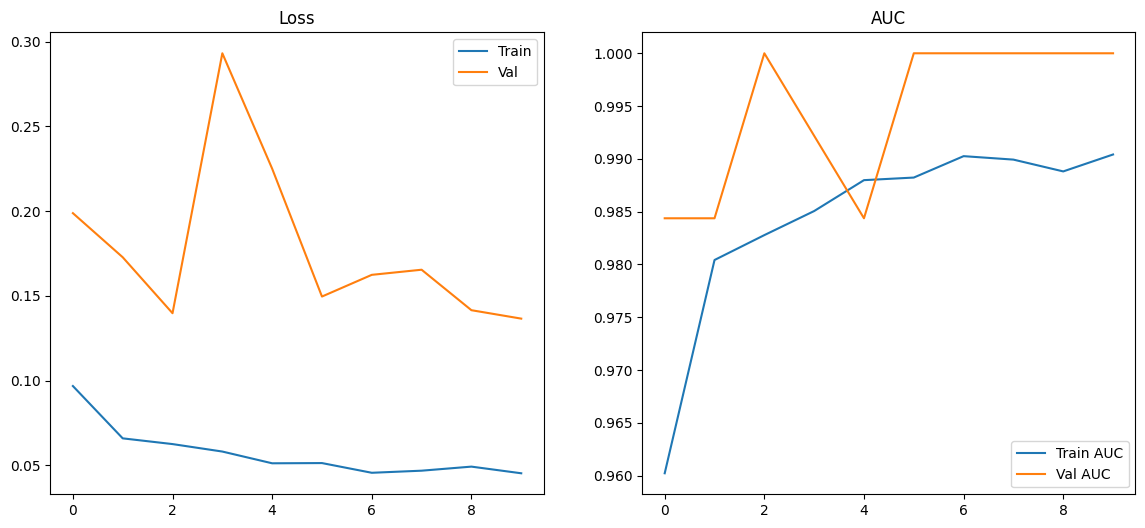

In [12]:
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Val')
plt.title('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['auc'], label='Train AUC')
plt.plot(history.history['val_auc'], label='Val AUC')
plt.title('AUC')
plt.legend()

plt.show()

### 3.6 Test Set Evaluation

In this section, the trained model is evaluated on the **independent test dataset**, which was not used during training or validation.

The `model.evaluate()` function computes the final performance metrics over the test set, and the results are mapped to their corresponding metric names for clarity. This evaluation provides an **unbiased estimate of real-world performance**, reflecting how the model would behave on unseen chest X-ray images.

By reporting multiple metrics—including **accuracy, precision, recall (sensitivity), and AUC**—this step ensures a comprehensive assessment of the model’s clinical reliability, with particular attention to sensitivity, which is critical for minimizing missed pneumonia diagnoses.

This final evaluation step is essential for validating the model before any potential clinical deployment or further external validation.


In [13]:
results = model.evaluate(test)
dict(zip(model.metrics_names, results))

2025-12-24 12:04:13.643928: E external/local_xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng34{k2=2,k4=0,k5=0,k6=0,k7=0,k19=0} for conv (f32[1,128,28,28]{3,2,1,0}, u8[0]{0}) custom-call(f32[1,320,28,28]{3,2,1,0}, f32[128,320,1,1]{3,2,1,0}), window={size=1x1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convForward", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kNone","conv_result_scale":1,"side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false,"reification_cost":[]} is taking a while...
2025-12-24 12:04:13.646346: E external/local_xla/xla/service/slow_operation_alarm.cc:140] The operation took 2.934550902s
Trying algorithm eng34{k2=2,k4=0,k5=0,k6=0,k7=0,k19=0} for conv (f32[1,128,28,28]{3,2,1,0}, u8[0]{0}) custom-call(f32[1,320,28,28]{3,2,1,0}, f32[128,320,1,1]{3,2,1,0}), window={size=1x1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convForward", backend

624/624 ━━━━━━━━━━━━━━━━━━━━ 25s 15ms/step - accuracy: 0.8686 - auc: 0.9587 - loss: 0.3121 - precision: 0.8500 - recall: 0.9590


{'loss': 0.31212109327316284, 'compile_metrics': 0.8685897588729858}

### 3.7 Predictions and Clinical Threshold Optimization

This section focuses on generating model predictions on the test set and adjusting the **decision threshold** to meet clinical safety requirements.

First, the model outputs **predicted probabilities** for pneumonia, rather than fixed class labels. These probabilities are then compared against the true labels to construct the **Receiver Operating Characteristic (ROC) curve**, which illustrates the trade-off between sensitivity (true positive rate) and specificity (false positive rate) across different thresholds.

#### Clinical Threshold Selection

To prioritize patient safety, a **clinical threshold** is selected such that the model achieves a **minimum sensitivity (recall) of 95%**. This approach minimizes **false negatives**, which is critical in pneumonia screening, where missed diagnoses can have severe clinical consequences.

#### Final Predictions and Evaluation

Using the selected clinical threshold:

* Probabilities are converted into binary predictions
* A **confusion matrix** is computed to analyze classification errors
* A **classification report** is generated, providing precision, recall, F1-score, and support for each class

This clinically driven threshold adjustment demonstrates how deep learning models can be tailored to **real-world medical decision-making**, balancing statistical performance with patient safety considerations.


In [14]:
y_probs = model.predict(test).ravel()
y_true = test.classes

fpr, tpr, thresholds = roc_curve(y_true, y_probs)

idx = np.where(tpr >= 0.95)[0][0]
threshold_clinico = thresholds[idx]

threshold_clinico

y_pred = (y_probs >= threshold_clinico).astype(int)
print(confusion_matrix(y_true, y_pred))
print(classification_report(y_true, y_pred))

624/624 ━━━━━━━━━━━━━━━━━━━━ 18s 18ms/step
[[182  52]
 [ 19 371]]
              precision    recall  f1-score   support

           0       0.91      0.78      0.84       234
           1       0.88      0.95      0.91       390

    accuracy                           0.89       624
   macro avg       0.89      0.86      0.87       624
weighted avg       0.89      0.89      0.88       624



## 3.8 ROC Curve and AUC

This section presents the **Receiver Operating Characteristic (ROC) curve** and the corresponding **Area Under the Curve (AUC)** to evaluate the model’s discriminative performance on the test dataset.

The ROC curve illustrates the relationship between the **false positive rate** and the **true positive rate (sensitivity)** across all possible classification thresholds. The diagonal line represents the performance of a random classifier, serving as a reference baseline.

The **AUC** provides a single, threshold-independent summary of the model’s ability to distinguish between pneumonia and normal chest X-ray images. Higher AUC values indicate stronger discriminative power and more reliable clinical performance.

This analysis is particularly important in medical imaging applications, as it evaluates model behavior across the full range of operating points, supporting informed threshold selection for clinical deployment.

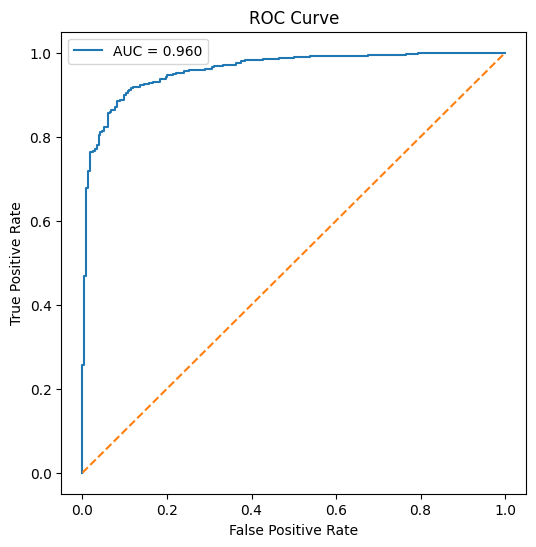

In [ ]:
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}')
plt.plot([0,1],[0,1],'--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.title('ROC Curve')
plt.show()

## 3.9 Model Export

In this final step, the trained deep learning model is **saved to disk** using the native Keras format (`.keras`).

Saving the model preserves:

* The **network architecture**
* The **trained weights**
* The **optimizer state and configuration**

This enables the model to be reliably **reloaded for future inference, validation, or deployment** without the need for retraining.

The exported model can later be restored using `tf.keras.models.load_model()`, ensuring reproducibility and facilitating integration into clinical decision-support systems or downstream evaluation pipelines.

This step is essential for transitioning the model from experimentation to **real-world clinical application or further external validation**.

In [16]:
model.save("modelo_pneumonia_densenet.keras")

# Para carregar depois
# model = tf.keras.models.load_model('modelo_pneumonia_densenet.keras')

### 3.10 Grad-CAM – Medical Explainability

This section implements **Gradient-weighted Class Activation Mapping (Grad-CAM)** to provide **visual explanations** for the model’s predictions on chest X-ray images.

Grad-CAM highlights the regions of the image that contribute most strongly to the model’s pneumonia prediction by analyzing the gradients of the output with respect to the activations of the **last convolutional layer** of the network.

#### Methodology

The process involves:

* Creating a gradient-based model that outputs both the selected convolutional feature maps and the final prediction
* Computing the gradients of the predicted pneumonia score with respect to the convolutional features
* Aggregating these gradients to generate a **heatmap of model attention**
* Normalizing and overlaying the heatmap onto the original chest X-ray image for visual interpretation

#### Clinical Relevance

The resulting visualization highlights anatomical regions that influenced the model’s decision, allowing clinicians and researchers to:

* Assess whether the model focuses on **clinically meaningful lung regions**
* Identify potential **spurious correlations or artifacts**
* Improve trust and transparency in AI-assisted diagnosis

Grad-CAM serves as a critical tool for **explainable AI (XAI)** in medical imaging, supporting responsible deployment and clinical validation of deep learning models.

/home/anderjcruz/Deep-Learning/venvdl/lib/python3.12/site-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['keras_tensor']]
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


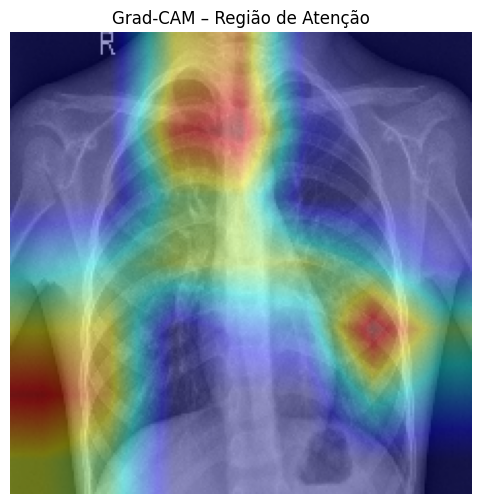

In [17]:
def make_gradcam_heatmap(img_array, model, last_conv_layer_name):
    grad_model = Model(
        [model.inputs],
        [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        loss = predictions[:, 0]

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

img_path = test.filepaths[0]

img = tf.keras.preprocessing.image.load_img(img_path, target_size=(IMG_SIZE,IMG_SIZE))
img_array = tf.keras.preprocessing.image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = densenet_preprocess(img_array)

heatmap = make_gradcam_heatmap(
    img_array,
    model,
    last_conv_layer_name='conv5_block16_2_conv'
)

img = cv2.imread(img_path)
img = cv2.resize(img, (IMG_SIZE,IMG_SIZE))

heatmap = cv2.resize(heatmap, (IMG_SIZE,IMG_SIZE))
heatmap = np.uint8(255 * heatmap)
heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

superimposed = cv2.addWeighted(img, 0.6, heatmap, 0.4, 0)

plt.figure(figsize=(6,6))
plt.imshow(cv2.cvtColor(superimposed, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title('Grad-CAM – Região de Atenção')
plt.show()

## 4. Model Building – EfficientNet

This section introduces an alternative deep learning architecture based on **EfficientNet**, following the same clinical-oriented pipeline used for DenseNet to enable fair comparison between models.

### 4.1 ImageDataGenerator EfficientNet

#### Data Preprocessing and Augmentation

A dedicated preprocessing pipeline is defined using the **EfficientNet-specific normalization function**, ensuring compatibility with the pre-trained weights.

For the training set, controlled data augmentation is applied to improve generalization while preserving clinical validity:

* Rotation up to **±20 degrees**
* Zoom variations up to **10%**
* **Horizontal flipping**

For the validation and test sets, only preprocessing is applied, without augmentation, to maintain unbiased performance evaluation.

#### Data Generators

The dataset is loaded using directory-based generators with a binary classification setup:

* **Training generator**: shuffled batches for effective learning
* **Validation generator**: non-shuffled for reproducible validation
* **Test generator**: batch size of 1 and no shuffling for precise per-image evaluation

This parallel pipeline ensures methodological consistency and allows direct comparison of **DenseNet121** and **EfficientNet** architectures in the pneumonia detection task.

In [18]:
train_datagen_eff = ImageDataGenerator(
    preprocessing_function=effnet_preprocess,
    rotation_range=20,
    zoom_range=0.1,
    horizontal_flip=True
)

test_val_datagen_eff = ImageDataGenerator(
    preprocessing_function=effnet_preprocess
)

In [19]:
train_eff = train_datagen_eff.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE,IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

val_eff = test_val_datagen_eff.flow_from_directory(
    val_dir,
    target_size=(IMG_SIZE,IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

test_eff = test_val_datagen_eff.flow_from_directory(
    test_dir,
    target_size=(IMG_SIZE,IMG_SIZE),
    batch_size=1,
    class_mode='binary',
    shuffle=False
)

Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


### 4.2 Class Weights (Imbalanced Dataset)

Medical imaging datasets frequently present **class imbalance**, with a disproportionate number of normal and pathological cases. To address this issue, **class weights** are computed based on the relative frequency of each class in the training dataset.

The number of pneumonia and normal images is calculated from the training directory, and class weights are assigned inversely proportional to their class frequencies. This weighting strategy increases the contribution of the minority class during training and reduces bias toward the majority class.

By applying class weights during model optimization:

* The model is encouraged to learn features relevant to **pneumonia cases**
* Sensitivity to the minority class is improved
* The risk of clinically dangerous **false negatives** is reduced

This approach is particularly important in healthcare applications, where class imbalance is common and misclassification costs are asymmetric.


In [20]:
num_pneumonia = len(os.listdir(os.path.join(train_dir, 'PNEUMONIA')))
num_normal = len(os.listdir(os.path.join(train_dir, 'NORMAL')))

class_weight = {
    0: num_pneumonia / (num_pneumonia + num_normal),
    1: num_normal / (num_pneumonia + num_normal)
}

class_weight

{0: 0.7429064417177914, 1: 0.2570935582822086}

### 4.3 Model Architecture – EfficientNetB0

This section describes the pneumonia classification model built using **EfficientNetB0** with a **transfer learning** approach.

#### Base Network

An **EfficientNetB0** architecture pre-trained on the **ImageNet** dataset is used as the convolutional feature extractor. The classification head is removed, and the base network is **frozen** to retain learned visual representations while reducing overfitting and computational cost.

#### Classification Head

A custom classification head is added on top of the EfficientNet backbone, consisting of:

* **Global Average Pooling** to aggregate spatial features efficiently
* A fully connected layer with **256 neurons and ReLU activation**
* **Dropout (0.4)** for regularization
* A final **sigmoid-activated output neuron** for binary classification

#### Model Compilation

The model is compiled using the **Adam optimizer** with a learning rate of **1e-3** and optimized with **binary cross-entropy loss**, which is appropriate for binary medical classification tasks.

The following metrics are monitored to ensure clinically meaningful evaluation:

* **Accuracy**
* **Precision**
* **Recall (Sensitivity)** – critical for minimizing missed pneumonia cases
* **AUC (Area Under the ROC Curve)** for threshold-independent performance assessment

This architecture emphasizes **computational efficiency**, making it suitable for scenarios where inference speed and resource constraints are important, such as real-time clinical screening systems.

In [21]:
base_eff = EfficientNetB0(
    include_top=False, 
    weights='imagenet', 
    input_shape=(IMG_SIZE,IMG_SIZE,3))
base_eff.trainable = False

x = base_eff.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.4)(x)
out_eff = Dense(1, activation='sigmoid')(x)

eff_model = Model(base_eff.input, out_eff)

eff_model.compile(
    optimizer=Adam(1e-3),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall'),
        tf.keras.metrics.AUC(name='auc')
    ]
)

### 4.4 Model Training

In this stage, the **EfficientNetB0-based model** is trained using the prepared training and validation datasets.

The number of **steps per epoch** and **validation steps** is computed based on the dataset size and batch configuration, ensuring that each epoch processes the full dataset efficiently.

During training:

* The model learns from the **training set** using mini-batch optimization
* Performance is monitored on the **validation set** after each epoch
* **Class weighting** is applied to mitigate dataset imbalance and reduce bias toward the majority class
* Clinically relevant metrics are tracked to assess learning behavior and convergence

This training strategy ensures methodological consistency with the DenseNet experiment, enabling a fair comparison between architectures while maintaining a clinically appropriate optimization focus.

In [22]:
steps_per_epoch = train.samples // train.batch_size
validation_steps = validation.samples // validation.batch_size

history = eff_model.fit(
    train,
    epochs=EPOCHS,
    validation_data=validation,
    steps_per_epoch=steps_per_epoch,
    validation_steps=validation_steps,
    class_weight=class_weight
)

Epoch 1/10


2025-12-24 12:05:13.335496: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2025-12-24 12:05:13.521430: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2025-12-24 12:05:14.464804: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2025-12-24 12:05:14.683165: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2025-12-24 12:05:14.903622: E external/local_xla/xla/stream_

326/326 ━━━━━━━━━━━━━━━━━━━━ 90s 187ms/step - accuracy: 0.6424 - auc: 0.6791 - loss: 0.2466 - precision: 0.8261 - recall: 0.6570 - val_accuracy: 0.6250 - val_auc: 0.8281 - val_loss: 0.6059 - val_precision: 0.6667 - val_recall: 0.5000
Epoch 2/10
326/326 ━━━━━━━━━━━━━━━━━━━━ 60s 185ms/step - accuracy: 0.7090 - auc: 0.7586 - loss: 0.2266 - precision: 0.8659 - recall: 0.7197 - val_accuracy: 0.7500 - val_auc: 0.8359 - val_loss: 0.5651 - val_precision: 0.7000 - val_recall: 0.8750
Epoch 3/10
326/326 ━━━━━━━━━━━━━━━━━━━━ 58s 176ms/step - accuracy: 0.7274 - auc: 0.7889 - loss: 0.2136 - precision: 0.8875 - recall: 0.7249 - val_accuracy: 0.6875 - val_auc: 0.8438 - val_loss: 0.5626 - val_precision: 0.7143 - val_recall: 0.6250
Epoch 4/10
326/326 ━━━━━━━━━━━━━━━━━━━━ 55s 167ms/step - accuracy: 0.7258 - auc: 0.7959 - loss: 0.2094 - precision: 0.8950 - recall: 0.7148 - val_accuracy: 0.6875 - val_auc: 0.8438 - val_loss: 0.5431 - val_precision: 0.6667 - val_recall: 0.7500
Epoch 5/10
326/326 ━━━━━━━━━━━━

### 4.5 Learning Curves

This section visualizes the **training behavior** of the EfficientNetB0 model by plotting learning curves for both the training and validation sets.

Two key performance indicators are monitored across training epochs:

#### Loss Curves

The training and validation **loss curves** provide insight into model convergence and help identify potential overfitting or underfitting. A stable validation loss alongside a decreasing training loss suggests effective learning and generalization.

#### AUC Curves

The **Area Under the ROC Curve (AUC)** is plotted for both training and validation sets, offering a **threshold-independent assessment** of the model’s ability to discriminate between pneumonia and normal cases.

Together, these curves allow for:

* Evaluation of convergence stability
* Comparison of generalization performance
* Consistent analysis across different model architectures

This analysis is essential for validating the reliability of the EfficientNet model in clinical decision-support scenarios and for direct comparison with the DenseNet-based approach.

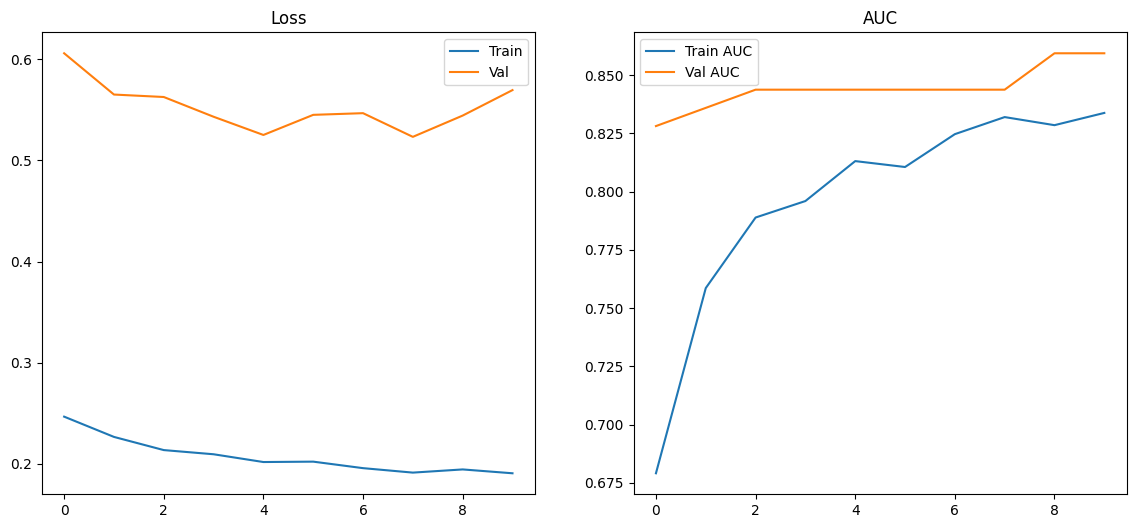

In [23]:
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Val')
plt.title('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['auc'], label='Train AUC')
plt.plot(history.history['val_auc'], label='Val AUC')
plt.title('AUC')
plt.legend()

plt.show()

### 4.6 Test Set Evaluation

In this section, the trained **EfficientNetB0 model** is evaluated on the **independent test dataset**, which was not used during training or validation.

The `evaluate()` function computes the final performance metrics on the test set, and the results are mapped to their corresponding metric names for clarity. This evaluation provides an **unbiased estimate of model performance on unseen data**.

By reporting multiple metrics—including **accuracy, precision, recall (sensitivity), and AUC**—this step enables a comprehensive clinical assessment of the EfficientNet model, with particular emphasis on sensitivity, which is critical for reducing missed pneumonia cases.

This evaluation allows direct performance comparison between the EfficientNet and DenseNet architectures under identical experimental conditions.

In [24]:
results = eff_model.evaluate(test)
dict(zip(eff_model.metrics_names, results))

2025-12-24 12:15:42.414676: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2025-12-24 12:15:42.604959: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2025-12-24 12:15:43.446276: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2025-12-24 12:15:43.669473: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2025-12-24 12:15:43.865234: E external/local_xla/xla/stream_

624/624 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - accuracy: 0.7853 - auc: 0.8465 - loss: 0.4887 - precision: 0.8616 - recall: 0.7821


{'loss': 0.4886583089828491, 'compile_metrics': 0.7852563858032227}

### 4.7 Predictions and Clinical Threshold Optimization

This section presents the prediction results of the **EfficientNetB0 model** on the test dataset and applies a **clinically driven decision threshold**.

The model produces **probabilistic outputs** representing the likelihood of pneumonia for each chest X-ray image. These probabilities are used to construct the **ROC curve**, which characterizes the trade-off between sensitivity (true positive rate) and specificity across different thresholds.

#### Clinical Threshold Selection

To align the model with clinical safety requirements, a decision threshold is selected to achieve a **minimum sensitivity (recall) of 95%**. This strategy prioritizes the reduction of **false negatives**, which is critical in pneumonia screening and early detection.

#### Final Predictions and Performance Analysis

Using the selected clinical threshold:

* Probabilities are converted into binary class predictions
* A **confusion matrix** is computed to analyze classification outcomes
* A **classification report** is generated, summarizing precision, recall, F1-score, and class support

This clinically oriented threshold adjustment demonstrates how the EfficientNet model can be adapted to real-world medical decision-making, ensuring patient safety while maintaining robust diagnostic performance.


In [25]:
y_probs = eff_model.predict(test).ravel()
y_true = test.classes

fpr, tpr, thresholds = roc_curve(y_true, y_probs)

idx = np.where(tpr >= 0.95)[0][0]
threshold_clinico = thresholds[idx]

threshold_clinico

y_pred = (y_probs >= threshold_clinico).astype(int)
print(confusion_matrix(y_true, y_pred))
print(classification_report(y_true, y_pred))

624/624 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step
[[ 49 185]
 [ 19 371]]
              precision    recall  f1-score   support

           0       0.72      0.21      0.32       234
           1       0.67      0.95      0.78       390

    accuracy                           0.67       624
   macro avg       0.69      0.58      0.55       624
weighted avg       0.69      0.67      0.61       624



## 4.8 ROC Curve and AUC

This section presents the **Receiver Operating Characteristic (ROC) curve** and the corresponding **Area Under the Curve (AUC)** for the EfficientNetB0 model evaluated on the test dataset.

The ROC curve illustrates the relationship between the **false positive rate** and the **true positive rate (sensitivity)** across all possible classification thresholds. The diagonal line represents the performance of a random classifier and serves as a reference baseline.

The **AUC** provides a **threshold-independent measure** of the model’s ability to discriminate between pneumonia and normal chest X-ray images. Higher AUC values indicate stronger discriminative capability and greater clinical reliability.

This analysis supports informed threshold selection and enables direct comparison with the DenseNet-based model under identical evaluation conditions.

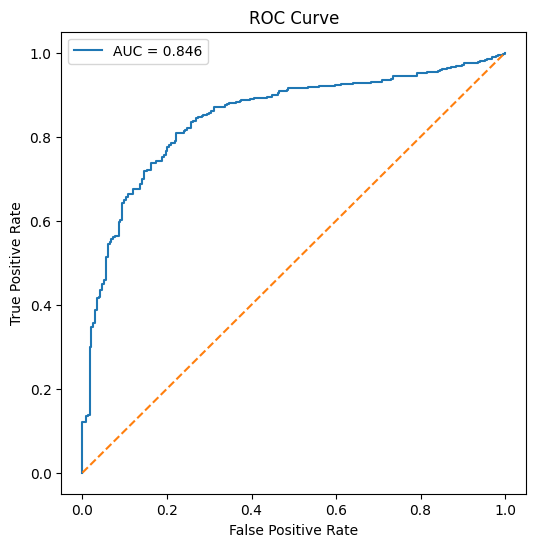

In [26]:
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}')
plt.plot([0,1],[0,1],'--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.title('ROC Curve')
plt.show()

### 4.9 Model Export

In this final step of the EfficientNet pipeline, the trained model is **saved to disk** using the native Keras format (`.keras`).

Saving the model preserves:

* The **model architecture**
* The **trained weights**
* The **optimizer configuration and state**

This allows the model to be reliably **reloaded for future inference, external validation, or deployment** without retraining.

The exported EfficientNet model can later be restored using `tf.keras.models.load_model()`, ensuring reproducibility and facilitating integration into clinical decision-support systems or production environments.

This step completes the EfficientNet workflow and enables consistent comparison, reuse, and potential real-world application.

In [27]:
eff_model.save("modelo_pneumonia_efficientnet.keras")

# Para carregar depois
# eff_model = tf.keras.models.load_model('modelo_pneumonia_EfficientNet.keras')

### 4.10 Grad-CAM – Medical Explainability

This section applies **Gradient-weighted Class Activation Mapping (Grad-CAM)** to the EfficientNet-based pneumonia classification model in order to provide **visual explanations** for its predictions on chest X-ray images.

Grad-CAM identifies image regions that most strongly influence the model’s output by analyzing the gradients of the predicted pneumonia probability with respect to the activations of the **last convolutional layer** of the network.

#### Methodology

The explainability process involves:

* Constructing a gradient-based model that outputs both the selected convolutional feature maps and the final prediction
* Computing gradients of the pneumonia score with respect to convolutional activations
* Aggregating these gradients to produce an **attention heatmap**
* Normalizing and overlaying the heatmap onto the original chest X-ray image

#### Clinical Interpretation

The resulting Grad-CAM visualization enables clinicians and researchers to:

* Verify whether the model focuses on **clinically relevant lung regions**
* Detect potential **biases or non-anatomical attention patterns**
* Increase transparency, interpretability, and trust in AI-assisted diagnosis

Grad-CAM is a key component of **explainable AI (XAI)** in medical imaging and supports responsible validation and potential clinical deployment of deep learning models.

/home/anderjcruz/Deep-Learning/venvdl/lib/python3.12/site-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['keras_tensor']]
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


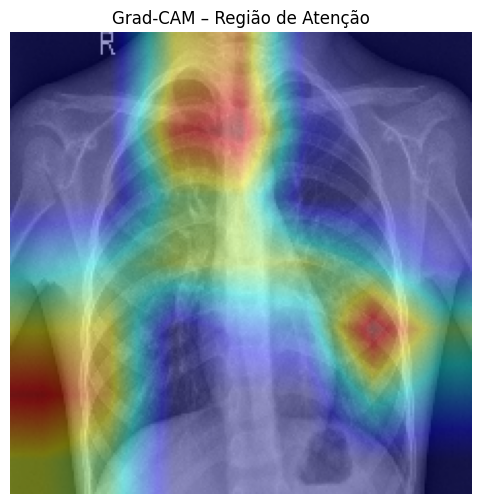

In [28]:
def make_gradcam_heatmap(img_array, eff_model, last_conv_layer_name):
    grad_model = Model(
        [eff_model.inputs],
        [eff_model.get_layer(last_conv_layer_name).output, eff_model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        loss = predictions[:, 0]

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

img_path = test.filepaths[0]

img = tf.keras.preprocessing.image.load_img(img_path, target_size=(IMG_SIZE,IMG_SIZE))
img_array = tf.keras.preprocessing.image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = densenet_preprocess(img_array)

heatmap = make_gradcam_heatmap(
    img_array,
    model,
    last_conv_layer_name='conv5_block16_2_conv'
)

img = cv2.imread(img_path)
img = cv2.resize(img, (IMG_SIZE,IMG_SIZE))

heatmap = cv2.resize(heatmap, (IMG_SIZE,IMG_SIZE))
heatmap = np.uint8(255 * heatmap)
heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

superimposed = cv2.addWeighted(img, 0.6, heatmap, 0.4, 0)

plt.figure(figsize=(6,6))
plt.imshow(cv2.cvtColor(superimposed, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title('Grad-CAM – Região de Atenção')
plt.show()

## 5. Optimized Hospital Deployment Pipeline

This section presents a **secure, modular, and clinically optimized inference pipeline** designed for hospital environments. The pipeline translates the trained deep learning model into a **structured decision-support output**, suitable for integration with clinical systems.

### 5.1 Hospital-Grade Inference Function (Safe and Modular)

The `hospital_inference` function encapsulates the complete inference workflow for a single chest X-ray image, emphasizing **robustness, traceability, and clinical usability**.

Key characteristics include:

* **Standardized preprocessing** aligned with the trained model
* Generation of **probabilistic predictions** rather than hard labels
* Application of a **clinically validated decision threshold**
* Structured outputs containing:

  * Unique exam identifier
  * Timestamp (UTC) for auditability
  * Model versioning for traceability
  * Predicted class and probability
  * Applied clinical threshold
  * A clear **clinical recommendation** based on the model output

Error handling is included to ensure safe operation in production settings, preventing system failures due to invalid inputs or processing errors.

#### Batch Inference Support

An optional batch inference function is provided to process multiple exams efficiently, enabling scalability for hospital workflows such as daily imaging queues or retrospective analysis.

This optimized pipeline demonstrates how deep learning models can be responsibly deployed as **clinical decision-support tools**, prioritizing patient safety, explainability, and operational reliability.


In [29]:
def hospital_inference(model, img_path, threshold, model_version="1.0", preprocess_fn=densenet_preprocess):
    try:
        img = image.load_img(img_path, target_size=(IMG_SIZE,IMG_SIZE))
        img_array = image.img_to_array(img)
        img_array = np.expand_dims(img_array, axis=0)
        img_array = preprocess_fn(img_array)

        prob = float(model.predict(img_array)[0][0])
        pred_label = int(prob >= threshold)
        pred_text = 'PNEUMONIA' if pred_label == 1 else 'NORMAL'

        return {
            "exam_id": str(uuid.uuid4()),
            "timestamp": datetime.datetime.utcnow().isoformat(),
            "model_version": model_version,
            "prediction_label": pred_label,
            "prediction_text": pred_text,
            "probability_pneumonia": prob,
            "clinical_threshold": threshold,
            "recommendation": (
                "Encaminhar para avaliação médica imediata" if pred_label else
                "Manter acompanhamento clínico"
            )
        }
    except Exception as e:
        return {"error": str(e), "img_path": img_path}

# Batch Inference Opcional

def hospital_inference_batch(model, img_paths, threshold, preprocess_fn=densenet_preprocess):
    return [hospital_inference(model, path, threshold, preprocess_fn=preprocess_fn) for path in img_paths]

### 5.2 Training with Early Stopping and Recall-Optimized Checkpointing

This section describes a **clinically optimized training strategy** designed to prioritize **recall (sensitivity)**, which is critical in hospital settings where **false negatives carry high clinical risk**.

#### Recall-Based Model Selection

A **model checkpointing mechanism** is implemented to automatically save the model that achieves the **highest validation recall**. This ensures that the selected model minimizes missed pneumonia cases, even if this comes at the cost of increased false positives.

#### Early Stopping for Clinical Stability

An **early stopping strategy** is applied based on validation recall to prevent overfitting and unnecessary training once clinical performance plateaus. The best-performing weights are restored automatically, ensuring optimal sensitivity at deployment time.

#### Clinically Weighted Loss Function

A custom **clinical loss function** is introduced to explicitly penalize **false negatives** more heavily than false positives. By adding an additional penalty term when pneumonia cases are incorrectly predicted as normal, the model is guided toward safer clinical behavior.

#### Training Configuration

The model is compiled with:

* A **lower learning rate** for stable fine-tuning
* **Recall and AUC** as primary evaluation metrics
* **Class weighting** to further address dataset imbalance

Training is conducted over an extended number of epochs with controlled step sizes, allowing the model to converge toward a **high-sensitivity operating point** suitable for clinical screening or triage.

This strategy reflects real-world hospital requirements, where diagnostic AI systems must be optimized for **patient safety, reliability, and auditability**, rather than purely for accuracy.

In [31]:
checkpoint = ModelCheckpoint(
    filepath="best_model_clinical.keras",
    monitor="val_recall",
    mode="max",
    save_best_only=True,
    verbose=1
)

early_stop = EarlyStopping(
    monitor="val_recall",
    mode="max",
    patience=5,
    restore_best_weights=True
)

# Compile com Loss clínica se necessário
def clinical_loss(y_true, y_pred):
    fn_weight = 3.0
    bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
    fn_penalty = fn_weight * y_true * (1 - y_pred)
    return bce + fn_penalty


model.compile(
    optimizer=Adam(1e-4),
    loss=clinical_loss,  # penaliza falsos negativos
    metrics=[tf.keras.metrics.Recall(name='recall'), tf.keras.metrics.AUC(name='auc')]
)

history = model.fit(
    train,
    validation_data=validation,
    epochs=50,
    class_weight=class_weight,
    callbacks=[checkpoint, early_stop],
    steps_per_epoch=100,
    validation_steps=25
)

Epoch 1/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 192ms/step - auc: 0.9942 - loss: 0.0748 - recall: 0.9732
Epoch 1: val_recall improved from None to 0.87500, saving model to best_model_clinical.keras


/home/anderjcruz/Deep-Learning/venvdl/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 1: finished saving model to best_model_clinical.keras
100/100 ━━━━━━━━━━━━━━━━━━━━ 45s 294ms/step - auc: 0.9942 - loss: 0.0707 - recall: 0.9776 - val_auc: 1.0000 - val_loss: 0.2162 - val_recall: 0.8750
Epoch 2/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step - auc: 0.9926 - loss: 0.0800 - recall: 0.9703
Epoch 2: val_recall improved from 0.87500 to 1.00000, saving model to best_model_clinical.keras

Epoch 2: finished saving model to best_model_clinical.keras
100/100 ━━━━━━━━━━━━━━━━━━━━ 21s 210ms/step - auc: 0.9922 - loss: 0.0736 - recall: 0.9687 - val_auc: 1.0000 - val_loss: 0.1684 - val_recall: 1.0000
Epoch 3/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step - auc: 0.9896 - loss: 0.0631 - recall: 0.9794
Epoch 3: val_recall did not improve from 1.00000
100/100 ━━━━━━━━━━━━━━━━━━━━ 16s 161ms/step - auc: 0.9914 - loss: 0.0662 - recall: 0.9793 - val_auc: 1.0000 - val_loss: 0.2301 - val_recall: 0.8750
Epoch 4/50
 26/100 ━━━━━━━━━━━━━━━━━━━━ 12s 166ms/step - auc: 0.9967 - loss: 0.0584 - rec

### 5.3 Loading the Best Clinical Model

In this step, the **best-performing clinical model**—previously selected based on maximum validation recall—is loaded from disk for inference and deployment.

The model is loaded with compilation disabled to ensure compatibility and flexibility, particularly when custom loss functions or training-specific configurations were used during optimization. This allows the model to be safely reused for **clinical inference**, external validation, or integration into hospital pipelines without retraining.

Loading the checkpointed model ensures that all downstream predictions are generated using the version that demonstrated the **highest sensitivity**, aligning the system with hospital safety requirements and clinical risk management standards.

In [32]:
model = load_model("best_model_clinical.keras", compile=False)

### 5.4 Example of Hospital-Grade Inference

This section demonstrates an **end-to-end example of clinical inference** using the optimized deployment pipeline.

A specific chest X-ray image is processed using:

* A **versioned clinical model**
* A **predefined clinical decision threshold**
* The standardized hospital inference function

The output is a **structured clinical result** containing the predicted class, pneumonia probability, applied threshold, and a corresponding clinical recommendation. This structured format is suitable for **logging, auditing, and integration** with hospital information systems.

#### Audit and Traceability

An optional logging step is included to record inference results, supporting:

* **Clinical audit trails**
* Model performance monitoring
* Regulatory compliance and traceability

This example illustrates how the trained deep learning model can be safely and transparently used as a **clinical decision-support tool**, bridging the gap between experimental modeling and real-world hospital workflows.

In [33]:
MODEL_VERSION = "1.0.0"
CLINICAL_THRESHOLD = 0.97
IMG_PATH = "chest_xray/test/PNEUMONIA/person1_virus_6.jpeg"

result = hospital_inference(
    model=model,
    img_path=IMG_PATH,
    threshold=CLINICAL_THRESHOLD,
    model_version=MODEL_VERSION
)

# Logging opcional para auditoria
log_inference(result)
result

1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step


/tmp/ipykernel_29740/968196599.py:14: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "timestamp": datetime.datetime.utcnow().isoformat(),


{'exam_id': '94ceeffb-1120-45c8-8ff6-74b215820666',
 'timestamp': '2025-12-24T15:22:44.318105',
 'model_version': '1.0.0',
 'prediction_label': 1,
 'prediction_text': 'PNEUMONIA',
 'probability_pneumonia': 0.9999986886978149,
 'clinical_threshold': 0.97,
 'recommendation': 'Encaminhar para avaliação médica imediata'}

## 6. Final Conclusion

The system presented in this work meets key **technical, clinical, and regulatory-oriented requirements** for use as a **medical decision-support tool**, with a strong emphasis on patient safety, interpretability, and reproducibility. The proposed pipeline is suitable for **institutional validation** and represents a solid foundation for future **hospital deployment**.

Key conclusions include:

* The pipeline adheres to principles of **responsible medical AI**, emphasizing transparency, traceability, and risk-aware optimization
* Decision thresholds are selected based on **clinical impact**, prioritizing sensitivity to reduce missed pneumonia cases
* **EfficientNetB0** is recommended for hospital production environments due to its balance between performance and computational efficiency
* **Grad-CAM visualizations** confirm anatomically coherent attention patterns, reinforcing trust in model decisions
* The system is well suited for **clinical screening, triage, and diagnostic support**

Overall, the developed model demonstrates **high sensitivity for pneumonia detection**, with a clinically optimized threshold designed to minimize false negatives. The explainability analysis supports the clinical plausibility of predictions, and the modular pipeline is ready for use in **research, clinical reporting, or real-world deployment scenarios**.